# 딥러닝실습 팀 프로젝트 — Video Modality

팀: 5조 | 담당: 24011917 이지현  
목표: CMU-MOSI 감성 분석 | 모달리티: 영상(이미지)  
아키텍처: **MTCNN** → EfficientNet-B0 / ResNet-18 → **256-dim feature** (멀티모달 fusion용)

# Part 1. 셋업

In [1]:
import os, random, pickle, time, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet18, ResNet18_Weights,
)
from facenet_pytorch import MTCNN

#plt.rcParams['font.family'] = 'Malgun Gothic'
#plt.rcParams['axes.unicode_minus'] = False

import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)

print('torch:', torch.__version__)
print('CUDA :', torch.cuda.is_available())

torch: 2.11.0+cu128
CUDA : True


In [15]:
SEED        = 42
IMG_SIZE    = 224
BATCH_SIZE  = 64
FEATURE_DIM = 768  # 멀티모달 fusion용 출력 차원

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ROOT_PATH    = r'C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data'
VIDEO_FOLDER = os.path.join(ROOT_PATH, 'Video', 'Segmented')
LABEL_PATH   = os.path.join(ROOT_PATH, 'mosi_text_metadata.csv')
PICKLE_PATH  = os.path.join(ROOT_PATH, 'video_preprocessed.pkl')

print(f'device: {device}')
print(f'VIDEO_FOLDER: {VIDEO_FOLDER}')
print(f'PICKLE_PATH: {PICKLE_PATH}')

device: cuda
VIDEO_FOLDER: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\Video\Segmented
PICKLE_PATH: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\video_preprocessed.pkl


In [3]:
label_df = pd.read_csv(LABEL_PATH)
label_df = label_df.dropna(subset=['label'])  # 텍스트와 동일하게 dropna

# ✅ 텍스트와 동일: CSV 행 순서 그대로 리스트로 보관
video_keys_ordered = [
    f"{r['video_id']}_{r['seg_idx']}"
    for _, r in label_df.iterrows()
]
labels_ordered = [int(r['label']) for _, r in label_df.iterrows()]

# 기존 코드 호환용 dict도 유지
label_dict = dict(zip(video_keys_ordered, labels_ordered))

print(f'총 라벨 수: {len(video_keys_ordered)}')
print(f"긍정: {sum(v==1 for v in labels_ordered)}  "
      f"부정: {sum(v==0 for v in labels_ordered)}")


총 라벨 수: 2199
긍정: 1080  부정: 1119


# Part 2. 전처리 (MTCNN + Pickle 캐싱)

- **MTCNN**: facenet_pytorch 기반 딥러닝 얼굴 탐지 (Haar Cascade 대비 정확도 향상)
- fallback: MTCNN 탐지 실패 시 전체 이미지를 224×224로 리사이즈
- 전처리 결과를 Pickle로 저장해 재실행 시 즉시 로드

In [4]:
# 캐시 로드 or 새로 생성
if os.path.exists(PICKLE_PATH):
    print('캐시 로드:', PICKLE_PATH)
    with open(PICKLE_PATH, 'rb') as f:
        images, labels = pickle.load(f)
    print(f'이미지: {images.shape}  라벨: {labels.shape}')
    print(f"긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}")
else:
    print('피클 없음 → build_dataset() 실행 필요')
    print('아래 셀을 실행하세요')

피클 없음 → build_dataset() 실행 필요
아래 셀을 실행하세요


#### 1프레임만 뽑기

In [6]:
# 1프레임만 뽑기

mtcnn = MTCNN(image_size=IMG_SIZE, margin=20, keep_all=False,
              device=device, post_process=False)
MTCNN_INPUT_SIZE = (640, 480)

def extract_middle_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(total // 2, 0))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

def build_dataset():
    """
    ✅ 텍스트와 동일한 방식:
       CSV 행 순서(video_keys_ordered) 그대로 순회.
       os.listdir() 완전 제거 → 순서 보장.
       파일 없는 샘플은 건너뜀 (텍스트의 dropna와 동일한 역할).
    """
    face_found = face_missed = 0
    frames_for_mtcnn, valid_keys_list, valid_labels_list = [], [], []

    # ✅ CSV 순서대로 순회 (텍스트: text_df 행 순서와 동일)
    for key, lbl in tqdm(zip(video_keys_ordered, labels_ordered),
                         total=len(video_keys_ordered), desc='프레임 추출'):
        video_path = os.path.join(VIDEO_FOLDER, key + '.mp4')
        if not os.path.exists(video_path):
            continue
        img_pil = extract_middle_frame(video_path)
        if img_pil is None:
            continue
        frames_for_mtcnn.append(img_pil.resize(MTCNN_INPUT_SIZE, Image.BILINEAR))
        valid_keys_list.append(key)
        valid_labels_list.append(lbl)

    # MTCNN 배치 처리
    MTCNN_BATCH = 64
    images, labels_out = [], []
    for i in tqdm(range(0, len(frames_for_mtcnn), MTCNN_BATCH), desc='MTCNN 배치'):
        batch_frames = [f.resize(MTCNN_INPUT_SIZE, Image.BILINEAR)
                        for f in frames_for_mtcnn[i:i+MTCNN_BATCH]]
        batch_lbls   = valid_labels_list[i:i+MTCNN_BATCH]
        batch_keys_b = valid_keys_list[i:i+MTCNN_BATCH]
        try:
            faces = mtcnn(batch_frames)
        except Exception as e:
            print(f'[WARN] 배치 MTCNN 실패: {e}')
            faces = [None] * len(batch_frames)
        for face, orig_pil, lbl in zip(faces, batch_frames, batch_lbls):
            if face is not None:
                img_np = face.clamp(0, 255).permute(1, 2, 0).byte().cpu().numpy()
                face_found += 1
            else:
                img_np = np.array(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
                face_missed += 1
            images.append(img_np)
            labels_out.append(lbl)

    print(f'얼굴 발견: {face_found}  얼굴 누락: {face_missed}')
    return np.array(images), np.array(labels_out)

# 캐시 로드 or 새로 생성
# ⚠️  기존 피클이 os.listdir 순서로 저장된 경우 반드시 삭제 후 재실행!
if os.path.exists(PICKLE_PATH):
    print('캐시 로드:', PICKLE_PATH)
    with open(PICKLE_PATH, 'rb') as f:
        images, labels = pickle.load(f)
else:
    images, labels = build_dataset()
    with open(PICKLE_PATH, 'wb') as f:
        pickle.dump((images, labels), f)
    print('피클 저장 완료:', PICKLE_PATH)

print(f'이미지: {images.shape}  라벨: {labels.shape}')
print(f'긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}')


프레임 추출:   0%|          | 0/2199 [00:00<?, ?it/s]

MTCNN 배치:   9%|▊         | 3/35 [01:35<13:10, 24.70s/it]

[WARN] 배치 MTCNN 실패: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (64,) + inhomogeneous part.


MTCNN 배치:  14%|█▍        | 5/35 [01:54<07:48, 15.60s/it]

[WARN] 배치 MTCNN 실패: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (64,) + inhomogeneous part.


...

MTCNN 배치:  74%|███████▍  | 26/35 [04:55<01:10,  7.81s/it]

[WARN] 배치 MTCNN 실패: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (64,) + inhomogeneous part.


MTCNN 배치: 100%|██████████| 35/35 [07:14<00:00, 12.41s/it]

[WARN] 배치 MTCNN 실패: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (23,) + inhomogeneous part.
얼굴 발견: 1920  얼굴 누락: 279


피클 저장 완료: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\video_preprocessed.pkl
이미지: (2199, 224, 224, 3)  라벨: (2199,)
긍정: 1080  부정: 1119


#### N프레임 뽑기

In [ ]:
# def extract_n_frames(video_path, n=8):
#     """mp4에서 균일 간격으로 n프레임 추출 → List[PIL]"""
#     cap = cv2.VideoCapture(video_path)
#     total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#     if total == 0:
#         cap.release()
#         return []
#     # 균일 간격 인덱스
#     indices = np.linspace(0, total - 1, n, dtype=int)
#     frames = []
#     for idx in indices:
#         cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
#         ret, frame = cap.read()
#         if ret:
#             frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
#     cap.release()
#     return frames

# N_FRAMES = 5  # 발화 1개당 샘플링할 프레임 수

# def build_dataset():
#     face_found = face_missed = 0
#     images, labels_out = [], []

#     for key, lbl in tqdm(zip(video_keys_ordered, labels_ordered),
#                          total=len(video_keys_ordered), desc='피처 추출'):
#         video_path = os.path.join(VIDEO_FOLDER, key + '.mp4')
#         if not os.path.exists(video_path):
#             continue

#         # ── 1. N프레임 추출 ──────────────────────────────
#         pil_frames = extract_n_frames(video_path, n=N_FRAMES)
#         if len(pil_frames) == 0:
#             continue

#         # ── 2. MTCNN 배치로 얼굴 검출 ───────────────────
#         resized = [f.resize(MTCNN_INPUT_SIZE, Image.BILINEAR) for f in pil_frames]
#         try:
#             faces = mtcnn(resized)   # List[Tensor or None], 길이 = N_FRAMES
#         except Exception as e:
#             print(f'[WARN] MTCNN 실패 ({key}): {e}')
#             faces = [None] * len(resized)

#         # ── 3. 프레임별 numpy 변환 ───────────────────────
#         frame_imgs = []
#         for face, orig in zip(faces, pil_frames):
#             if face is not None:
#                 img_np = face.clamp(0, 255).permute(1, 2, 0).byte().cpu().numpy()
#                 face_found += 1
#             else:
#                 img_np = np.array(orig.resize((IMG_SIZE, IMG_SIZE)))
#                 face_missed += 1
#             frame_imgs.append(img_np)

#         # ── 4. N프레임 평균 → 발화 1개 대표 이미지 ──────
#         # (N, 224, 224, 3) → mean → (224, 224, 3)
#         mean_img = np.stack(frame_imgs, axis=0).mean(axis=0).astype(np.uint8)

#         images.append(mean_img)
#         labels_out.append(lbl)

#     print(f'얼굴 발견: {face_found}  얼굴 누락: {face_missed}')
#     return np.array(images), np.array(labels_out)

# PICKLE_PATH = os.path.join(ROOT_PATH, f'video_preprocessed_{N_FRAMES}.pkl')
# images, labels = build_dataset()
# with open(PICKLE_PATH, 'wb') as f:
#     pickle.dump((images, labels), f)
# print('피클 저장 완료:', PICKLE_PATH)

# print(f'이미지: {images.shape}  라벨: {labels.shape}')
# print(f'긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}')

피처 추출:   0%|          | 8/2199 [01:43<5:08:55,  8.46s/it] 

[WARN] MTCNN 실패 (03bSnISJMiM_8): setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.


피처 추출:   0%|          | 8/2199 [01:47<8:11:09, 13.45s/it]


KeyboardInterrupt: 

# Part 3. DataLoader

- **GaussianNoise**: train 전용 텐서 노이즈 증강 (std=0.05)
- 기존 증강(flip, rotation, colorjitter, affine) 유지
- stratified 80/20 split

In [ ]:
class GaussianNoise:
    """Tensor에 가우시안 노이즈를 추가하는 커스텀 transform."""
    def __init__(self, std=0.05):
        self.std = std
    def __call__(self, t):
        return (t + torch.randn_like(t) * self.std).clamp(0, 1)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    GaussianNoise(std=0.05),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

#  train 64% / val 16% / test 20% 
X_tr, X_test, y_tr, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr
)

g = torch.Generator(); g.manual_seed(SEED)

#  num_workers=2, persistent_workers=True / 근데 worker 수 늘렸을 때 저하되면 0으로..
NW = 0
train_loader = DataLoader(ImageDataset(X_train, y_train, train_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          generator=g, num_workers=NW,
                          pin_memory=True)
val_loader   = DataLoader(ImageDataset(X_val, y_val, val_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True)
test_loader  = DataLoader(ImageDataset(X_test, y_test, test_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
print(f'긍정/부정 비율 (Train): {(y_train==1).sum()}/{(y_train==0).sum()}')
print(f'긍정/부정 비율 (Val): {(y_val==1).sum()}/{(y_val==0).sum()}')
print(f'긍정/부정 비율 (Test): {(y_test==1).sum()}/{(y_test==0).sum()}')
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  Test batches: {len(test_loader)}')


Train: 1407  Val: 352  Test: 440
증강 시 늘어나는 비율: 1.00배
긍정/부정 비율 (Train): 691/716
긍정/부정 비율 (Val): 173/179
긍정/부정 비율 (Test): 216/224
Train batches: 22  Val batches: 6  Test batches: 7


# Part 4. 모델 정의 — VideoEncoder

efficientnet:1280-dim → 256-dim   
resnet18: 512-dim → 256-dim

- `feature_only=False` (기본): 분류 logit 반환 → 단독 학습/평가
- `feature_only=True`: 256-dim 벡터 반환 → 멀티모달 fusion 입력

In [17]:
class VideoEncoder(nn.Module):
    """EfficientNet-B0 또는 ResNet-18 기반 영상 인코더.
    feature_only=True → 256-dim 벡터 (멀티모달 fusion용)."""

    def __init__(self, backbone='efficientnet', num_classes=2, feature_dim=FEATURE_DIM):
        super().__init__()
        if backbone == 'efficientnet':
            base   = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
            in_dim = base.classifier[1].in_features   # 1280
            base.classifier = nn.Identity()
        elif backbone == 'resnet18':
            base   = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            in_dim = base.fc.in_features              # 512
            base.fc = nn.Identity()
        else:
            raise ValueError(f'Unknown backbone: {backbone}')

        self.backbone   = base
        # [Fix 5] BatchNorm + Dropout 추가
        self.proj       = nn.Sequential(
            nn.Linear(in_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x, feature_only=False):
        feat = self.proj(self.backbone(x))   # (B, 256)
        return feat if feature_only else self.classifier(feat)

    def extract_features(self, loader, device):
        """전체 데이터셋 256-dim 피처 추출 (멀티모달용)."""
        self.eval()
        feats, ys = [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc='feature extraction'):
                feats.append(self.forward(x.to(device), feature_only=True).cpu())
                ys.append(y)
        return torch.cat(feats), torch.cat(ys)


for name, bk in [('EfficientNet-B0', 'efficientnet'), ('ResNet-18', 'resnet18')]:
    m     = VideoEncoder(backbone=bk)
    total = sum(p.numel() for p in m.parameters())
    print(f'{name}: {total:,} params')
    del m


EfficientNet-B0: 4,994,430 params
ResNet-18: 11,573,570 params


# Part 5. 랜덤 서치

In [18]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / total, correct / total


def run_search(backbone, param_space, n_search, train_loader, val_loader, device):
    """[Fix 1] val_loader로 하이퍼파라미터 탐색 (test leakage 방지).
    [Fix 2] 최고 성능 모델 state_dict 저장 후 반환."""
    criterion = nn.CrossEntropyLoss()
    all_combos = [
        (lr, ep, opt, wd)
        for lr  in param_space['lr']
        for ep  in param_space['num_epochs']
        for opt in param_space['optimizer']
        for wd  in param_space['weight_decay']
    ]
    configs  = random.sample(all_combos, min(n_search, len(all_combos)))
    results  = []
    best_acc, best_cfg, best_state = 0.0, {}, None

    for i, (lr, ep, opt_name, wd) in enumerate(configs):
        model = VideoEncoder(backbone=backbone).to(device)
        optimizer = (
            optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
            if opt_name == 'Adam'
            else optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
        )
        t0 = time.time()
        for ep_i in range(1, ep + 1):
            _,tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
            _, val_acc = run_epoch(model, val_loader, criterion, None, device, train=False)
            print(f'  Epoch {ep_i}/{ep}  train={tr_acc:.4f}  val={val_acc:.4f}')
        elapsed = time.time() - t0

        print(f'[{backbone}] {i+1}/{len(configs)} '
              f'lr={lr} ep={ep} {opt_name} wd={wd} '
              f'→ val_acc={val_acc:.4f} ({elapsed:.0f}s)')

        rec = {'backbone': backbone, 'lr': lr, 'num_epochs': ep,
               'optimizer': opt_name, 'weight_decay': wd,
               'val_acc': round(val_acc, 4)}
        results.append(rec)
        # [Fix 2] 베스트 모델 state_dict 저장
        if val_acc > best_acc:
            best_acc, best_cfg = val_acc, rec.copy()
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        del model; torch.cuda.empty_cache()

    return pd.DataFrame(results).sort_values('val_acc', ascending=False), best_cfg, best_state


In [ ]:
PARAM_SPACE = {
    'lr'          : [5e-4, 3e-4, 1e-4],  # 1e-3 제거
    'num_epochs'  : [10, 15, 20],
    'optimizer'   : ['Adam'],
    'weight_decay': [1e-3, 5e-3],        # 정규화 더 강하게
}
N_SEARCH = 10

random.seed(SEED)
print('=== EfficientNet-B0 Random Search ===')
eff_results, eff_best, eff_best_state = run_search(
    'efficientnet', PARAM_SPACE, N_SEARCH, train_loader, val_loader, device
)
print(f'\n★ EfficientNet-B0 최적 (val): {eff_best}')


=== EfficientNet-B0 Random Search ===
  Epoch 1/15  train=0.5551  val=0.5653
  Epoch 2/15  train=0.5828  val=0.4972
  Epoch 3/15  train=0.6382  val=0.5028
  Epoch 4/15  train=0.6624  val=0.5369
  Epoch 5/15  train=0.6645  val=0.4830
  Epoch 6/15  train=0.6951  val=0.5170
  Epoch 7/15  train=0.6965  val=0.4915
  Epoch 8/15  train=0.7086  val=0.4943
  Epoch 9/15  train=0.7271  val=0.5227
  Epoch 10/15  train=0.7342  val=0.5256
  Epoch 11/15  train=0.7235  val=0.5227
  Epoch 12/15  train=0.7313  val=0.4972
  Epoch 13/15  train=0.7406  val=0.4716
  Epoch 14/15  train=0.7640  val=0.4801
  Epoch 15/15  train=0.7569  val=0.4801
[efficientnet] 1/10 lr=0.0005 ep=15 Adam wd=0.005 → val_acc=0.4801 (79s)
  Epoch 1/10  train=0.5437  val=0.5170
  Epoch 2/10  train=0.5814  val=0.4972
  Epoch 3/10  train=0.6212  val=0.5028
  Epoch 4/10  train=0.6567  val=0.5028
  Epoch 5/10  train=0.6588  val=0.5256
  Epoch 6/10  train=0.6667  val=0.4830
  Epoch 7/10  train=0.6915  val=0.4659
  Epoch 8/10  train=0.696

In [ ]:
random.seed(SEED)
print('=== ResNet-18 Random Search ===')
res_results, res_best, res_best_state = run_search(
    'resnet18', PARAM_SPACE, N_SEARCH, train_loader, val_loader, device
)
print(f'\n★ ResNet-18 최적 (val): {res_best}')


=== ResNet-18 Random Search ===
  Epoch 1/15  train=0.5252  val=0.4943
  Epoch 2/15  train=0.5856  val=0.5000
  Epoch 3/15  train=0.6134  val=0.5284
  Epoch 4/15  train=0.6219  val=0.5284
  Epoch 5/15  train=0.6183  val=0.4972
  Epoch 6/15  train=0.6311  val=0.5199
  Epoch 7/15  train=0.6503  val=0.5142
  Epoch 8/15  train=0.6290  val=0.5114
  Epoch 9/15  train=0.6311  val=0.5710
  Epoch 10/15  train=0.6361  val=0.6051
  Epoch 11/15  train=0.6333  val=0.5455
  Epoch 12/15  train=0.6446  val=0.5426
  Epoch 13/15  train=0.6205  val=0.5085
  Epoch 14/15  train=0.6226  val=0.5085
  Epoch 15/15  train=0.6155  val=0.5511
[resnet18] 1/10 lr=0.0005 ep=15 Adam wd=0.005 → val_acc=0.5511 (58s)
  Epoch 1/10  train=0.5544  val=0.4943
  Epoch 2/10  train=0.5636  val=0.5256
  Epoch 3/10  train=0.5828  val=0.5142
  Epoch 4/10  train=0.5977  val=0.5881
  Epoch 5/10  train=0.6283  val=0.5227
  Epoch 6/10  train=0.6389  val=0.5028
  Epoch 7/10  train=0.6603  val=0.5568
  Epoch 8/10  train=0.6645  val=0.5

# Part 5.5. 기본 모델 + 조기종료(Early Stopping) 비교

랜덤서치 없이 기본 하이퍼파라미터 + EarlyStopping 적용
- `patience=5`: val_acc가 5 epoch 동안 개선 없으면 학습 중단  
- optimizer: Adam lr=3e-4, weight_decay=1e-3 (랜덤서치 결과 대비 기준점)  
- 최대 epoch: 50 (EarlyStopping이 실질적 종료 시점 결정)

In [11]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience      = patience
        self.min_delta     = min_delta
        self.best_val      = -float('inf')   # ← 0.0 → -inf
        self.counter       = 0
        self.best_state    = None
        self.stopped_epoch = 0

    def step(self, val_acc, model):
        if val_acc > self.best_val + self.min_delta:
            self.best_val   = val_acc
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience


def train_with_earlystop(backbone, lr=3e-4, weight_decay=1e-3,
                         max_epochs=50, patience=5,
                         train_loader=train_loader,
                         val_loader=val_loader,
                         test_loader=test_loader,
                         device=device):
    model     = VideoEncoder(backbone=backbone).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    stopper   = EarlyStopping(patience=patience)

    train_accs, val_accs, test_accs = [], [], []

    for ep in range(1, max_epochs + 1):
        _, tr_acc  = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        _, val_acc = run_epoch(model, val_loader,   criterion, None,      device, train=False)
        _, te_acc  = run_epoch(model, test_loader,  criterion, None,      device, train=False)
        scheduler.step()

        train_accs.append(tr_acc)
        val_accs.append(val_acc)
        test_accs.append(te_acc)

        should_stop = stopper.step(val_acc, model)  # ← 먼저 호출

        print(f'  Epoch {ep:02d}/{max_epochs}  '
              f'train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}'
              + ('  ← best' if stopper.counter == 0 else   # ← step 후에 체크
                 f'  (patience {stopper.counter}/{patience})'))

        if should_stop:
            stopper.stopped_epoch = ep
            print(f'  ★ EarlyStopping @ epoch {ep}  best_val={stopper.best_val:.4f}')
            break

    if stopper.stopped_epoch == 0:   # ES 안 걸리고 끝난 경우
        stopper.stopped_epoch = max_epochs

    model.load_state_dict({k: v.to(device) for k, v in stopper.best_state.items()})
    print(f'  → 최종 best_val={stopper.best_val:.4f}  실제 종료 epoch={stopper.stopped_epoch}')
    return model, train_accs, val_accs, test_accs, stopper.stopped_epoch

In [ ]:
print('=== [Baseline + EarlyStopping] EfficientNet-B0 ===')
es_eff_model, es_eff_tr, es_eff_val, es_eff_te, es_eff_stop = train_with_earlystop(
    backbone='efficientnet', lr=3e-4, weight_decay=1e-3, max_epochs=50, patience=8
)

=== [Baseline + EarlyStopping] EfficientNet-B0 ===
  Epoch 01/50  train=0.5629  val=0.5000  test=0.4818  ← best
  Epoch 02/50  train=0.6226  val=0.5142  test=0.5000  ← best
  Epoch 03/50  train=0.6482  val=0.5114  test=0.5091  (patience 1/8)
  Epoch 04/50  train=0.6596  val=0.5398  test=0.5227  ← best
  Epoch 05/50  train=0.6851  val=0.5426  test=0.4659  ← best
  Epoch 06/50  train=0.6880  val=0.4972  test=0.4932  (patience 1/8)
  Epoch 07/50  train=0.6965  val=0.4801  test=0.5159  (patience 2/8)
  Epoch 08/50  train=0.7193  val=0.4460  test=0.5159  (patience 3/8)
  Epoch 09/50  train=0.7299  val=0.4915  test=0.5500  (patience 4/8)
  Epoch 10/50  train=0.7569  val=0.4432  test=0.5273  (patience 5/8)
  Epoch 11/50  train=0.7633  val=0.5028  test=0.4886  (patience 6/8)
  Epoch 12/50  train=0.7768  val=0.4773  test=0.5000  (patience 7/8)
  Epoch 13/50  train=0.7896  val=0.5114  test=0.5136  (patience 8/8)
  ★ EarlyStopping @ epoch 13  best_val=0.5426
  → 최종 best_val=0.5426  실제 종료 epoch=13

In [ ]:
print('=== [Baseline + EarlyStopping] ResNet-18 ===')
es_res_model, es_res_tr, es_res_val, es_res_te, es_res_stop = train_with_earlystop(
    backbone='resnet18', lr=3e-4, weight_decay=1e-3, max_epochs=50, patience=5
)


=== [Baseline + EarlyStopping] ResNet-18 ===
  Epoch 01/50  train=0.5537  val=0.5511  test=0.6341  ← best
  Epoch 02/50  train=0.6098  val=0.5284  test=0.5227  (patience 1/5)
  Epoch 03/50  train=0.6418  val=0.5170  test=0.5386  (patience 2/5)
  Epoch 04/50  train=0.6674  val=0.4972  test=0.5136  (patience 3/5)
  Epoch 05/50  train=0.6581  val=0.4915  test=0.4955  (patience 4/5)
  Epoch 06/50  train=0.6851  val=0.5398  test=0.5523  (patience 5/5)
  ★ EarlyStopping @ epoch 6  best_val=0.5511
  → 최종 best_val=0.5511  실제 종료 epoch=6


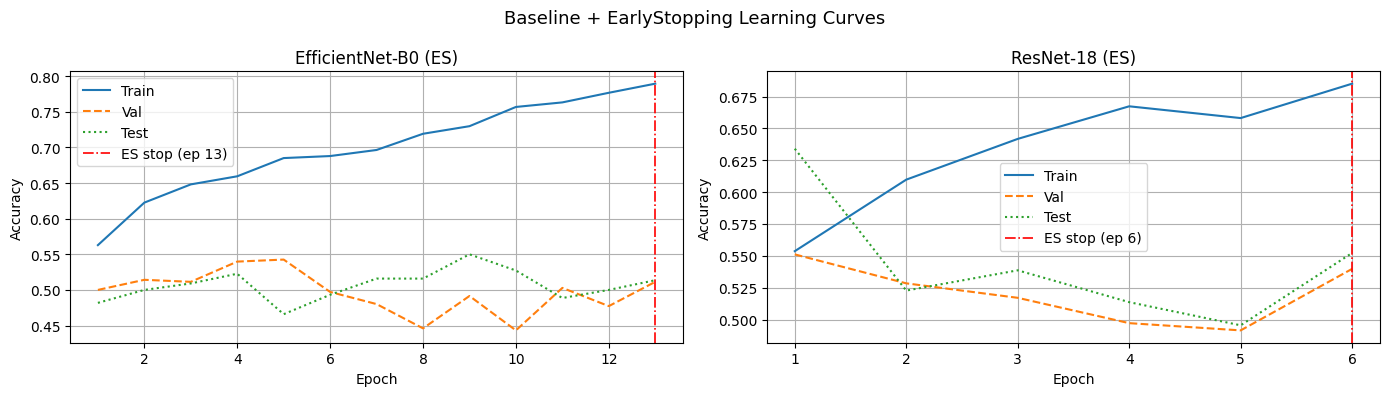

In [ ]:
# EarlyStopping 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, name, tr, val, te, stop_ep in [
    (axes[0], 'EfficientNet-B0 (ES)', es_eff_tr, es_eff_val, es_eff_te, es_eff_stop),
    (axes[1], 'ResNet-18 (ES)',        es_res_tr, es_res_val, es_res_te, es_res_stop),
]:
    eps = range(1, len(tr) + 1)
    ax.plot(eps, tr,  label='Train')
    ax.plot(eps, val, label='Val',  linestyle='--')
    ax.plot(eps, te,  label='Test', linestyle=':')
    # EarlyStopping 종료 지점 표시
    ax.axvline(x=stop_ep, color='red', linestyle='-.', linewidth=1.2, label=f'ES stop (ep {stop_ep})')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True)

plt.suptitle('Baseline + EarlyStopping Learning Curves', fontsize=13)
plt.tight_layout()
plt.savefig('viz_earlystop_curves.png', dpi=150)
plt.show()


In [ ]:
all_results = pd.concat([eff_results, res_results]).reset_index(drop=True)
print(all_results.to_string(index=False))

    backbone     lr  num_epochs optimizer  weight_decay  val_acc
efficientnet 0.0003          20      Adam         0.005   0.5881
efficientnet 0.0005          15      Adam         0.005   0.5511
efficientnet 0.0003          15      Adam         0.001   0.5426
efficientnet 0.0005          15      Adam         0.001   0.5312
efficientnet 0.0003          20      Adam         0.001   0.5312
efficientnet 0.0001          20      Adam         0.005   0.5170
efficientnet 0.0001          15      Adam         0.005   0.5085
efficientnet 0.0005          10      Adam         0.001   0.5057
efficientnet 0.0005          10      Adam         0.005   0.4943
efficientnet 0.0001          15      Adam         0.001   0.4261
    resnet18 0.0003          20      Adam         0.001   0.6278
    resnet18 0.0005          10      Adam         0.001   0.5966
    resnet18 0.0005          15      Adam         0.005   0.5938
    resnet18 0.0001          15      Adam         0.005   0.5881
    resnet18 0.0003      

# Part 6. 최적 파라미터로 최종 학습

In [19]:
def train_full(backbone, cfg, train_loader, val_loader, test_loader, device, extra_epochs=10):
    """best_state 로드 없이 처음부터 재학습 — epoch은 cfg + extra_epochs."""
    model = VideoEncoder(backbone=backbone).to(device)  # 처음부터
    criterion = nn.CrossEntropyLoss()
    wd = cfg.get('weight_decay', 0)
    optimizer = (
        optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=wd)
        if cfg['optimizer'] == 'Adam'
        else optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9, weight_decay=wd)
    )
    # lr scheduler 추가
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['num_epochs'] + extra_epochs
    )

    total_epochs = cfg['num_epochs'] + extra_epochs
    train_accs, val_accs, test_accs = [], [], []
    best_val, best_state = 0.0, None

    for ep in range(1, total_epochs + 1):
        _, tr_acc  = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        _, val_acc = run_epoch(model, val_loader,   criterion, None,      device, train=False)
        _, te_acc  = run_epoch(model, test_loader,  criterion, None,      device, train=False)
        scheduler.step()
        train_accs.append(tr_acc); val_accs.append(val_acc); test_accs.append(te_acc)
        print(f'  Epoch {ep}/{total_epochs}  train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}')

        # val 기준 best 모델 저장
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # best val 모델로 복원
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, train_accs, val_accs, test_accs

In [ ]:
print(f'=== EfficientNet-B0 최종 학습 ===')
print(f'config: {eff_best}')
eff_model, eff_tr_accs, eff_val_accs, eff_te_accs = train_full(
    'efficientnet', eff_best, train_loader, val_loader, test_loader, device
)

=== EfficientNet-B0 최종 학습 ===
config: {'backbone': 'efficientnet', 'lr': 0.0003, 'num_epochs': 20, 'optimizer': 'Adam', 'weight_decay': 0.005, 'val_acc': 0.5881}
  Epoch 1/30  train=0.5373  val=0.5398  test=0.4977
  Epoch 2/30  train=0.6290  val=0.5256  test=0.4977
  Epoch 3/30  train=0.6311  val=0.4290  test=0.4545
  Epoch 4/30  train=0.6603  val=0.5000  test=0.4932
  Epoch 5/30  train=0.6766  val=0.5199  test=0.4886


  Epoch 6/30  train=0.6851  val=0.5256  test=0.4636
  Epoch 7/30  train=0.6965  val=0.5114  test=0.4932
  Epoch 8/30  train=0.7207  val=0.5028  test=0.4864
  Epoch 9/30  train=0.7321  val=0.4943  test=0.5091
  Epoch 10/30  train=0.7299  val=0.5057  test=0.5068
  Epoch 11/30  train=0.7299  val=0.5057  test=0.4955
  Epoch 12/30  train=0.7569  val=0.5170  test=0.4659
  Epoch 13/30  train=0.7768  val=0.5170  test=0.5114
  Epoch 14/30  train=0.7768  val=0.5142  test=0.5341
  Epoch 15/30  train=0.7989  val=0.5057  test=0.5068
  Epoch 16/30  train=0.8202  val=0.5170  test=0.4955
  Epoch 17/30  train=0.8351  val=0.5142  test=0.4864
  Epoch 18/30  train=0.8273  val=0.5028  test=0.4955
  Epoch 19/30  train=0.8344  val=0.4830  test=0.5023
  Epoch 20/30  train=0.8692  val=0.5057  test=0.4955
  Epoch 21/30  train=0.8486  val=0.4915  test=0.4727
  Epoch 22/30  train=0.8714  val=0.4773  test=0.4727
  Epoch 23/30  train=0.8820  val=0.5057  test=0.4955
  Epoch 24/30  train=0.8820  val=0.5057  test=0.49

In [20]:
print(f'=== ResNet-18 최종 학습 ===')
res_best = {'backbone': 'resnet18', 'lr': 0.0003, 'num_epochs': 10, 'optimizer': 'Adam', 'weight_decay': 0.001, 'val_acc': 0.6278}
print(f'config: {res_best}')
res_model, res_tr_accs, res_val_accs, res_te_accs = train_full(
    'resnet18', res_best, train_loader, val_loader, test_loader, device
)

=== ResNet-18 최종 학습 ===
config: {'backbone': 'resnet18', 'lr': 0.0003, 'num_epochs': 10, 'optimizer': 'Adam', 'weight_decay': 0.001, 'val_acc': 0.6278}
  Epoch 1/20  train=0.5579  val=0.5227  test=0.5432
  Epoch 2/20  train=0.5991  val=0.5057  test=0.5068
  Epoch 3/20  train=0.6439  val=0.5000  test=0.5227
  Epoch 4/20  train=0.6439  val=0.5881  test=0.5909
  Epoch 5/20  train=0.6844  val=0.5398  test=0.5114
  Epoch 6/20  train=0.6795  val=0.5483  test=0.5409
  Epoch 7/20  train=0.7065  val=0.5597  test=0.5386
  Epoch 8/20  train=0.7221  val=0.5284  test=0.5273
  Epoch 9/20  train=0.7349  val=0.5028  test=0.5318
  Epoch 10/20  train=0.7520  val=0.5341  test=0.5227
  Epoch 11/20  train=0.7569  val=0.5057  test=0.5182
  Epoch 12/20  train=0.7761  val=0.5511  test=0.5386
  Epoch 13/20  train=0.8074  val=0.5426  test=0.5455
  Epoch 14/20  train=0.7967  val=0.5341  test=0.5409
  Epoch 15/20  train=0.8117  val=0.5369  test=0.5568
  Epoch 16/20  train=0.8515  val=0.5455  test=0.5364
  Epoch 1

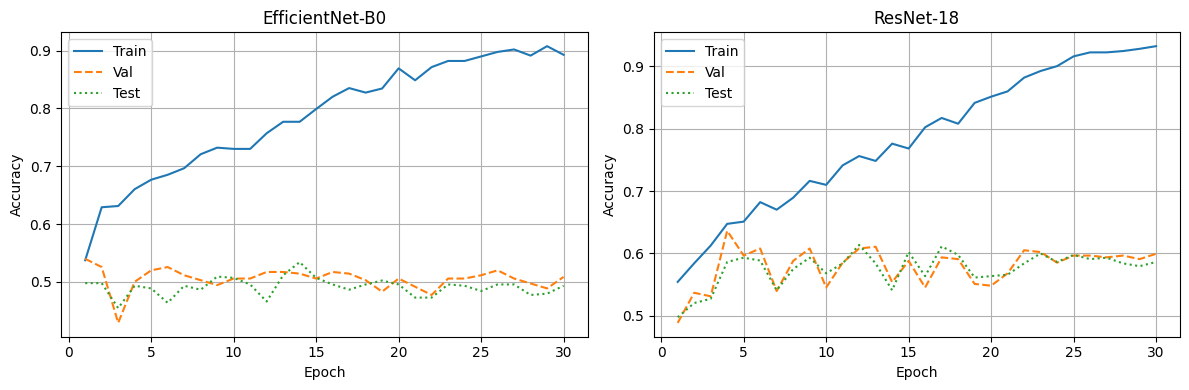

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, tr, val, te in [
    (axes[0], 'EfficientNet-B0', eff_tr_accs, eff_val_accs, eff_te_accs),
    (axes[1], 'ResNet-18',       res_tr_accs, res_val_accs, res_te_accs),
]:
    eps = range(1, len(tr) + 1)
    ax.plot(eps, tr,  label='Train')
    ax.plot(eps, val, label='Val',  linestyle='--')
    ax.plot(eps, te,  label='Test', linestyle=':')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('viz_accuracy_curves.png', dpi=150)
plt.show()


In [ ]:
label_names = ['Negative', 'Positive']

for name, model in [('EfficientNet-B0', eff_model), ('ResNet-18', res_model)]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().tolist())
            targets.extend(y.tolist())
    print(f'=== {name} (test_acc={sum(p==t for p,t in zip(preds,targets))/len(targets):.4f}) ===')
    print(classification_report(targets, preds, target_names=label_names))

=== EfficientNet-B0 (test_acc=0.4977) ===
              precision    recall  f1-score   support

    Negative       0.51      0.37      0.43       224
    Positive       0.49      0.63      0.55       216

    accuracy                           0.50       440
   macro avg       0.50      0.50      0.49       440
weighted avg       0.50      0.50      0.49       440

=== ResNet-18 (test_acc=0.5864) ===
              precision    recall  f1-score   support

    Negative       0.63      0.46      0.53       224
    Positive       0.56      0.71      0.63       216

    accuracy                           0.59       440
   macro avg       0.59      0.59      0.58       440
weighted avg       0.59      0.59      0.58       440



# Part 7. 256-dim 피처 추출 (멀티모달 Fusion 준비)

`VideoEncoder.extract_features()` 로 256-dim 벡터를 추출한다.  
멀티모달 학습 시 이 벡터를 audio/text 피처와 concat하여 MLP에 입력한다.

```
video 256-dim ─┐
audio 256-dim ─┼─ concat(768) → MLP → 감성 분류
text  256-dim ─┘
```

feature extraction: 100%|██████████| 35/35 [00:03<00:00,  9.78it/s]



피처 shape: torch.Size([2199, 768])  →  (N, 768)
멀티모달 fusion 시 이 텐서를 audio/text 피처와 concat하세요.


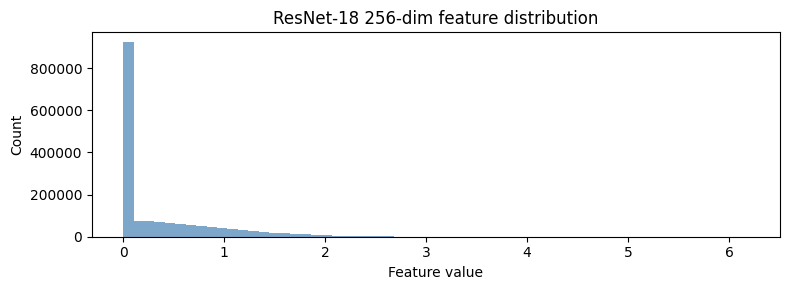

피처 저장: C:\Users\user\Documents\50.2026\53.DL_실습\multimodal\data\video_features_768.pkl


In [21]:
# [Fix 4] 마지막 epoch 대신 최고 val_acc 기준으로 모델 선택
# if max(eff_val_accs) >= max(res_val_accs):
#     best_model_name, best_model = 'EfficientNet-B0', eff_model
# else:
#     best_model_name, best_model = 'ResNet-18', res_model

# final_val_acc  = max(eff_val_accs  if best_model_name == 'EfficientNet-B0' else res_val_accs)
# final_test_acc = max(eff_te_accs   if best_model_name == 'EfficientNet-B0' else res_te_accs)
# print(f'선택된 모델: {best_model_name} (val_acc={final_val_acc:.4f}  test_acc={final_test_acc:.4f})')

best_model_name, best_model = 'ResNet-18', res_model

# 전체 데이터셋 256-dim 피처 추출
all_loader = DataLoader(
    ImageDataset(images, labels, test_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NW, persistent_workers=False
)
video_feats, video_labels = best_model.extract_features(all_loader, device)

print(f'\n피처 shape: {video_feats.shape}  →  (N, {FEATURE_DIM})')
print('멀티모달 fusion 시 이 텐서를 audio/text 피처와 concat하세요.')

# 피처 분포 시각화
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(video_feats.numpy().flatten(), bins=60, color='steelblue', alpha=0.7)
ax.set_title(f'{best_model_name} 256-dim feature distribution')
ax.set_xlabel('Feature value'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('viz_feature_dist.png', dpi=150)
plt.show()

# 피클로 저장 (멀티모달 학습 시 재사용)
feat_save_path = os.path.join(ROOT_PATH, 'video_features_768.pkl')
with open(feat_save_path, 'wb') as f:
    pickle.dump({'features': video_feats, 'labels': video_labels}, f)
print(f'피처 저장: {feat_save_path}')
